<a href="https://colab.research.google.com/github/Shrushti88/Machine-Vision/blob/main/CM23006_3MV.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Practical 3

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files

Upload Reference Image


Saving 6x11kKucqa753BI6PXTMV8WKqItxT_vTru5OQPlOuV20jYe25d7tEVRHWl2xJ3HJhrXVZucoi4Wno5cQokOM6fWD5Lk2AydIlmPZGXwL48Yt0ymetul7kp5JVXXz10f_h1JoQq4HLaIGzDXBMoBRNhseeM6gMsHtXemBCU2MtnNQ644bIur4QSB7qCkl9DAh.jpg to 6x11kKucqa753BI6PXTMV8WKqItxT_vTru5OQPlOuV20jYe25d7tEVRHWl2xJ3HJhrXVZucoi4Wno5cQokOM6fWD5Lk2AydIlmPZGXwL48Yt0ymetul7kp5JVXXz10f_h1JoQq4HLaIGzDXBMoBRNhseeM6gMsHtXemBCU2MtnNQ644bIur4QSB7qCkl9DAh.jpg


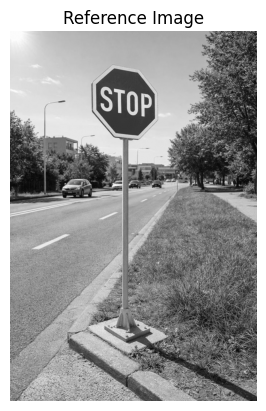

In [2]:
print("Upload Reference Image")
uploaded = files.upload()

ref_name = next(iter(uploaded))
ref = cv2.imread(ref_name, 0)

plt.imshow(ref, cmap='gray')
plt.title("Reference Image")
plt.axis("off")
plt.show()

Upload Test Image


Saving SsXKNcsQjkp_JARyXiGj5_GJiRSlNs2z79yZp_bLBr3iD9kjEw6hYN-262u6z9dl8bkM5YZgqoBGlCoyPhFBzc_ZV5BpQXDZhSAHR2RMX8pV5rrMv3bN-jp9GAm-XmJotuPjTjv-RePY5QsmSVpDzuE6pikqK9ZT4A9dNjLy8vh1HilRJi-WuUHPfpOfyDJ_.jpg to SsXKNcsQjkp_JARyXiGj5_GJiRSlNs2z79yZp_bLBr3iD9kjEw6hYN-262u6z9dl8bkM5YZgqoBGlCoyPhFBzc_ZV5BpQXDZhSAHR2RMX8pV5rrMv3bN-jp9GAm-XmJotuPjTjv-RePY5QsmSVpDzuE6pikqK9ZT4A9dNjLy8vh1HilRJi-WuUHPfpOfyDJ_.jpg
Saving 6x11kKucqa753BI6PXTMV8WKqItxT_vTru5OQPlOuV20jYe25d7tEVRHWl2xJ3HJhrXVZucoi4Wno5cQokOM6fWD5Lk2AydIlmPZGXwL48Yt0ymetul7kp5JVXXz10f_h1JoQq4HLaIGzDXBMoBRNhseeM6gMsHtXemBCU2MtnNQ644bIur4QSB7qCkl9DAh.jpg to 6x11kKucqa753BI6PXTMV8WKqItxT_vTru5OQPlOuV20jYe25d7tEVRHWl2xJ3HJhrXVZucoi4Wno5cQokOM6fWD5Lk2AydIlmPZGXwL48Yt0ymetul7kp5JVXXz10f_h1JoQq4HLaIGzDXBMoBRNhseeM6gMsHtXemBCU2MtnNQ644bIur4QSB7qCkl9DAh (1).jpg
Saving mv2-06.pdf to mv2-06.pdf
Saving lv4vmL-xQRo0PcZcwtzTaF0rZBS-RaBPFESTwoo34yGKuxadmj998SxrqGqcwjnWmrgnpTJzozKRFjojFV-4dT2-HYsxQ_oaBv8TQXY2i0dhVX1WBZS8fboh4lHtAiO160VThkwoHZLkUNW4t2QgV

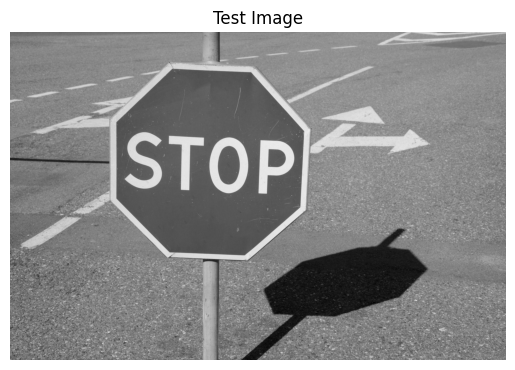

In [4]:
print("Upload Test Image")
uploaded = files.upload()

test_name = next(iter(uploaded))
test = cv2.imread(test_name, 0)

plt.imshow(test, cmap='gray')
plt.title("Test Image")
plt.axis("off")
plt.show()

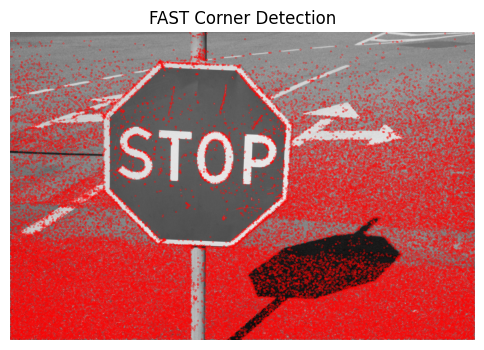

In [5]:
fast = cv2.FastFeatureDetector_create()

kp = fast.detect(test, None)

corner_img = cv2.drawKeypoints(
    test,
    kp,
    None,
    color=(255,0,0)
)

plt.figure(figsize=(6,6))
plt.imshow(corner_img, cmap='gray')
plt.title("FAST Corner Detection")
plt.axis("off")
plt.show()

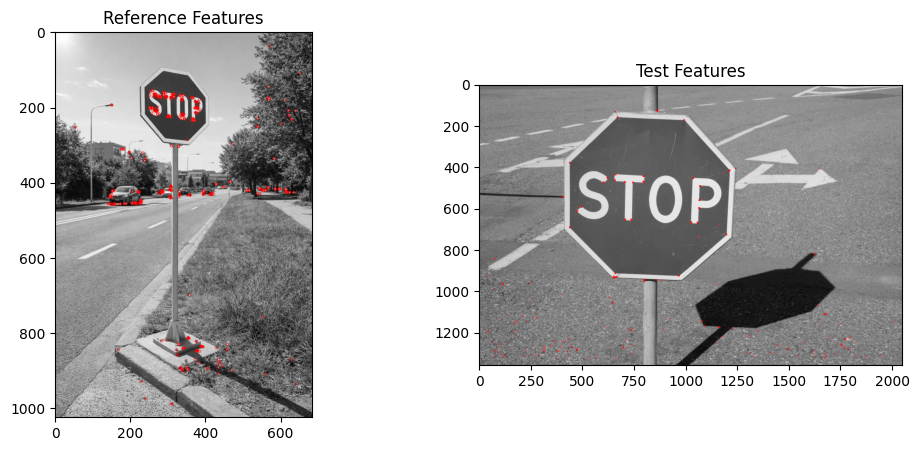

In [6]:
orb = cv2.ORB_create()

kp1, des1 = orb.detectAndCompute(ref, None)
kp2, des2 = orb.detectAndCompute(test, None)

orb_ref = cv2.drawKeypoints(ref, kp1, None, color=(255,0,0))
orb_test = cv2.drawKeypoints(test, kp2, None, color=(255,0,0))

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.imshow(orb_ref, cmap='gray')
plt.title("Reference Features")

plt.subplot(1,2,2)
plt.imshow(orb_test, cmap='gray')
plt.title("Test Features")

plt.show()

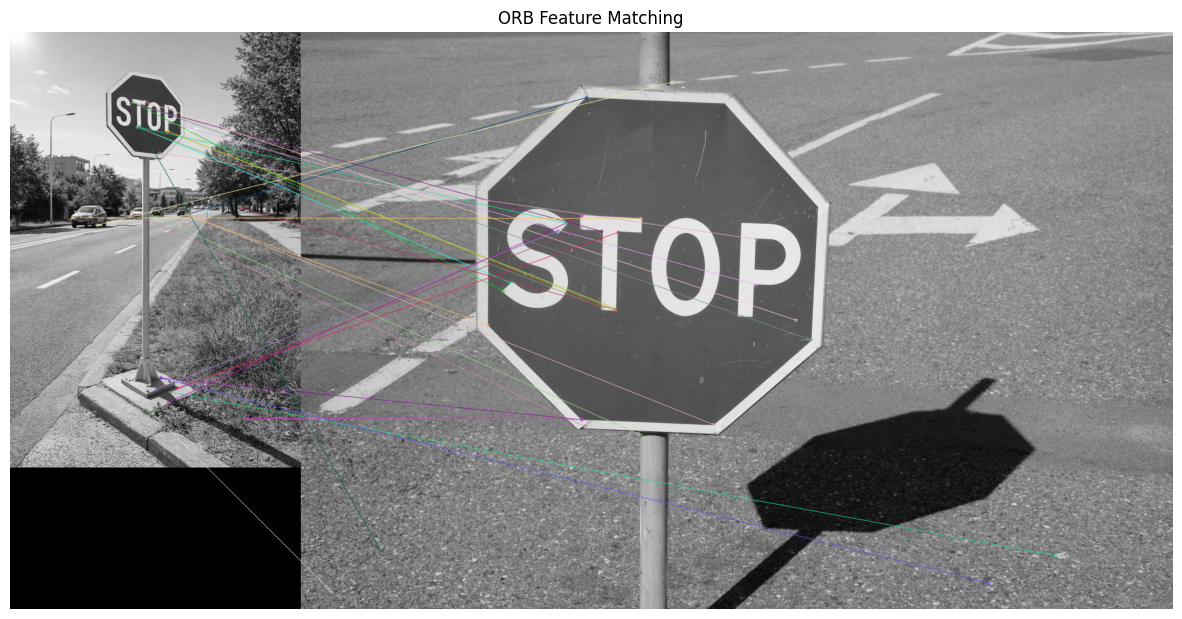

In [7]:
bf = cv2.BFMatcher(cv2.NORM_HAMMING, crossCheck=True)

matches = bf.match(des1, des2)

matches = sorted(matches, key=lambda x:x.distance)

matched = cv2.drawMatches(
    ref,
    kp1,
    test,
    kp2,
    matches[:30],
    None,
    flags=2
)

plt.figure(figsize=(15,8))
plt.imshow(matched)
plt.title("ORB Feature Matching")
plt.axis("off")
plt.show()

In [8]:
print("Reference Keypoints :", len(kp1))
print("Test Keypoints :", len(kp2))
print("Good Matches :", len(matches[:30]))

Reference Keypoints : 500
Test Keypoints : 500
Good Matches : 30
